# Data Exploration

In [1]:
import mne
import numpy as np

In [2]:
PATH = "siena-scalp-eeg-database-1.0.0"
raw = mne.io.read_raw_edf(f"{PATH}/PN00/PN00-3.edf", preload=True) #f"{PATH}/PN05/PN05-2.edf"
print(raw.info)  # sanity check: channels, sfreq, duration

Extracting EDF parameters from siena-scalp-eeg-database-1.0.0/PN00/PN00-3.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 1284607  =      0.000 ...  2508.998 secs...


/var/folders/7m/6x53syk95817z_4293gmf06w0000gn/T/ipykernel_61766/973990467.py:2: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(f"{PATH}/PN00/PN00-3.edf", preload=True) #f"{PATH}/PN05/PN05-2.edf"
/var/folders/7m/6x53syk95817z_4293gmf06w0000gn/T/ipykernel_61766/973990467.py:2: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(f"{PATH}/PN00/PN00-3.edf", preload=True) #f"{PATH}/PN05/PN05-2.edf"
/var/folders/7m/6x53syk95817z_4293gmf06w0000gn/T/ipykernel_61766/973990467.py:2: RuntimeWarning: Highpass cutoff frequency 15.91549 is greater than lowpass cutoff frequency 15.0, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_edf(f"{PATH}/PN00/PN00-3.edf", preload=True) #f"{PATH}/PN05/PN05-2.edf"


<Info | 8 non-empty values
 bads: []
 ch_names: EEG Fp1, EEG F3, EEG C3, EEG P3, EEG O1, EEG F7, EEG T3, EEG T5, ...
 chs: 35 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 256.0 Hz
 meas_date: 2016-01-01 18:15:44 UTC
 nchan: 35
 projs: []
 sfreq: 512.0 Hz
 subject_info: <subject_info | his_id: >
>


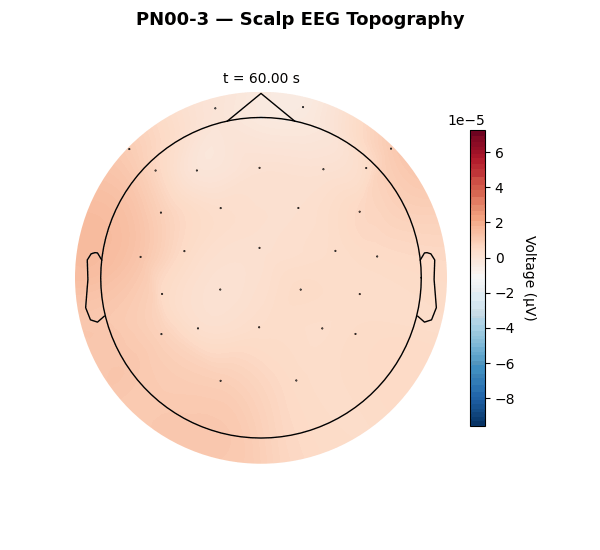

In [8]:
from utils import plot_eeg_gif
from IPython.display import Image

plot_eeg_gif(raw, save_path="img.gif", fps=3)
Image("img.gif")


Using matplotlib as 2D backend.


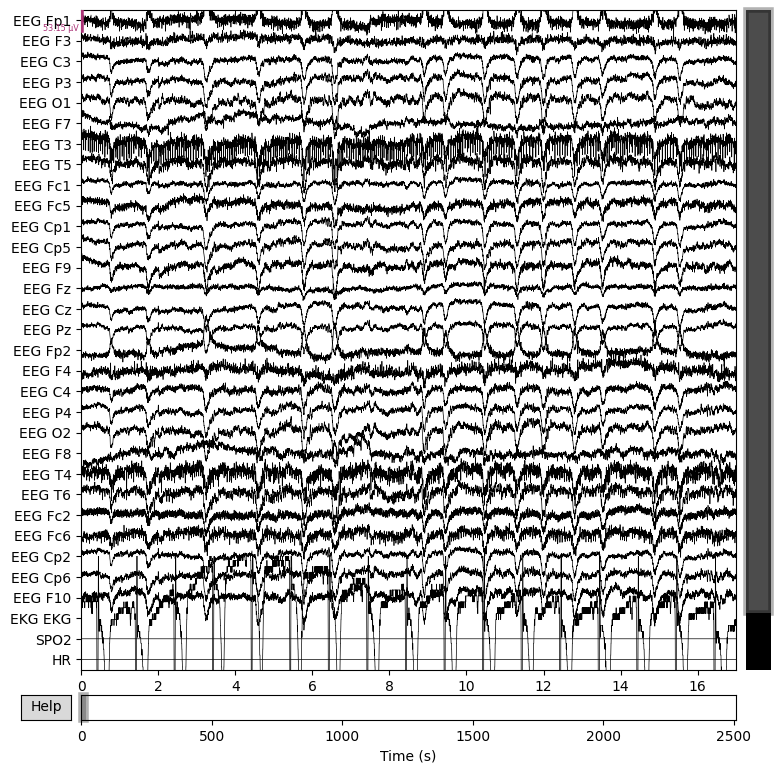

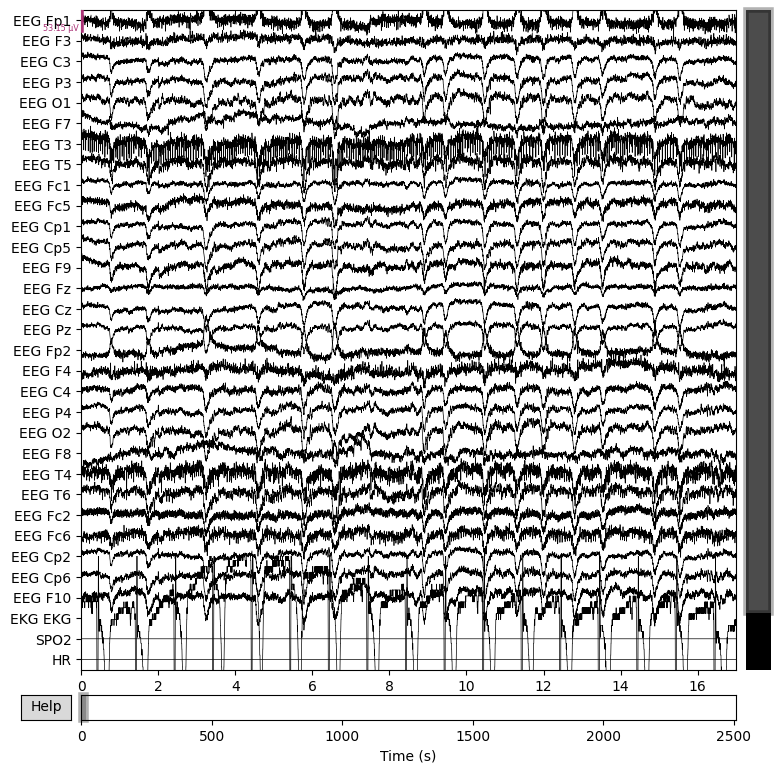

In [3]:
raw.plot(duration=17, n_channels=32, scalings='auto')

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 1691 samples (3.303 s)

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 49 - 51 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 49.38
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 49.12 Hz)
- Upper passband edg

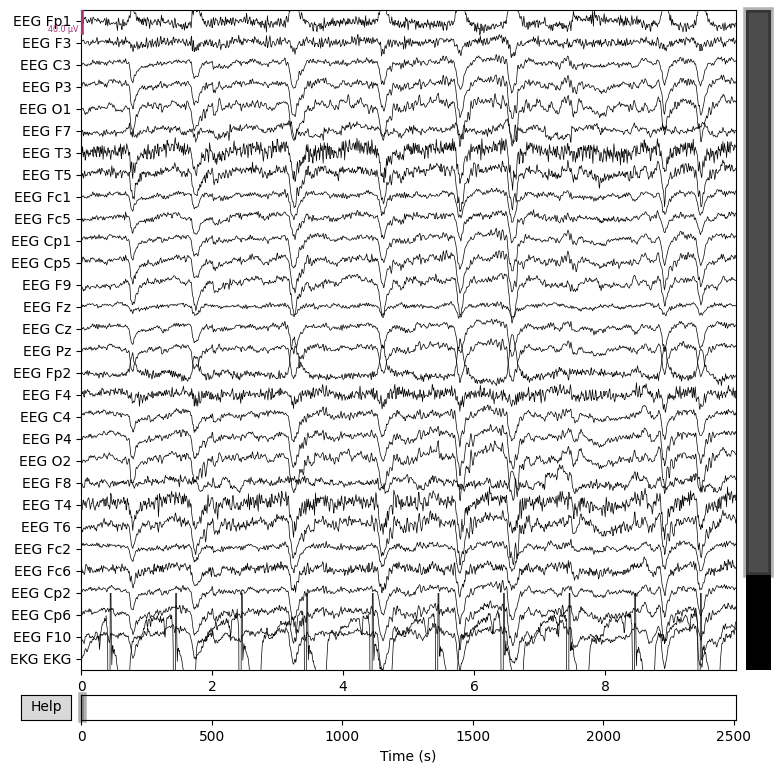

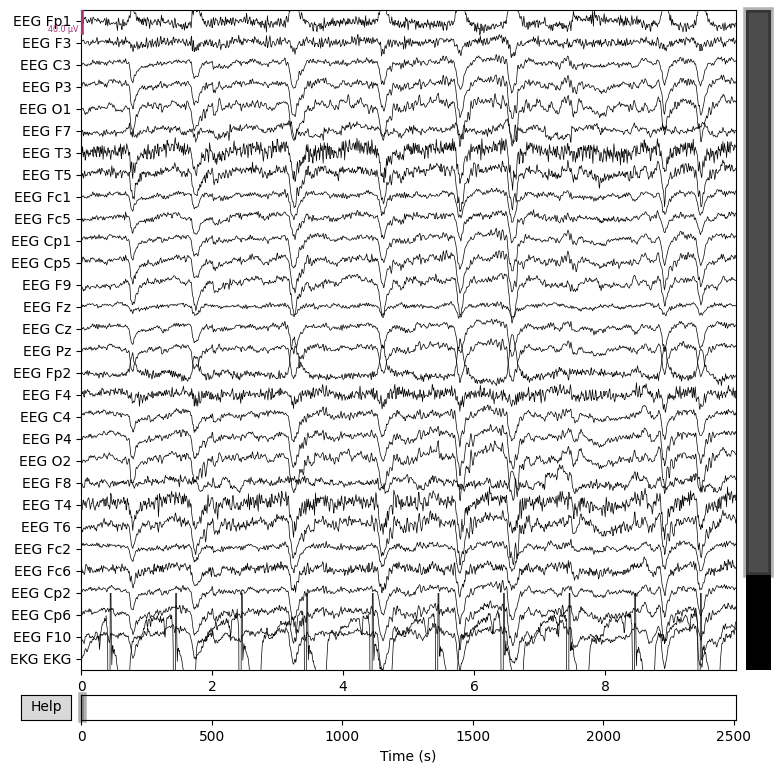

In [ ]:
raw.filter(l_freq=1.0, h_freq=40.0)        # bandpass: drift + high-freq noise
raw.notch_filter(freqs=50)                  # 50 Hz (Europe)
raw.notch_filter(freqs=60)                  # 60 Hz (US)
raw.plot(duration=10, n_channels=30)

In [5]:
def moving_average(signal, window_size):
    return np.convolve(signal, np.ones(window_size)/window_size, mode='same')

def iterative_moving_average(signal, max_window_size):
    smoothed_signal = signal
    for window_size in range(1, max_window_size + 1):
        smoothed_signal = moving_average(smoothed_signal, window_size)
    return smoothed_signal

max_window_size = 10

def apply_filter(data):  # data shape: (n_channels, n_times)
    return np.array([iterative_moving_average(ch, max_window_size) for ch in data])

raw.apply_function(
    lambda ch: iterative_moving_average(ch, max_window_size),
    channel_wise=True
)

<RawEDF | PN00-3.edf, 35 x 1284608 (2509.0 s), ~343.1 MiB, data loaded>

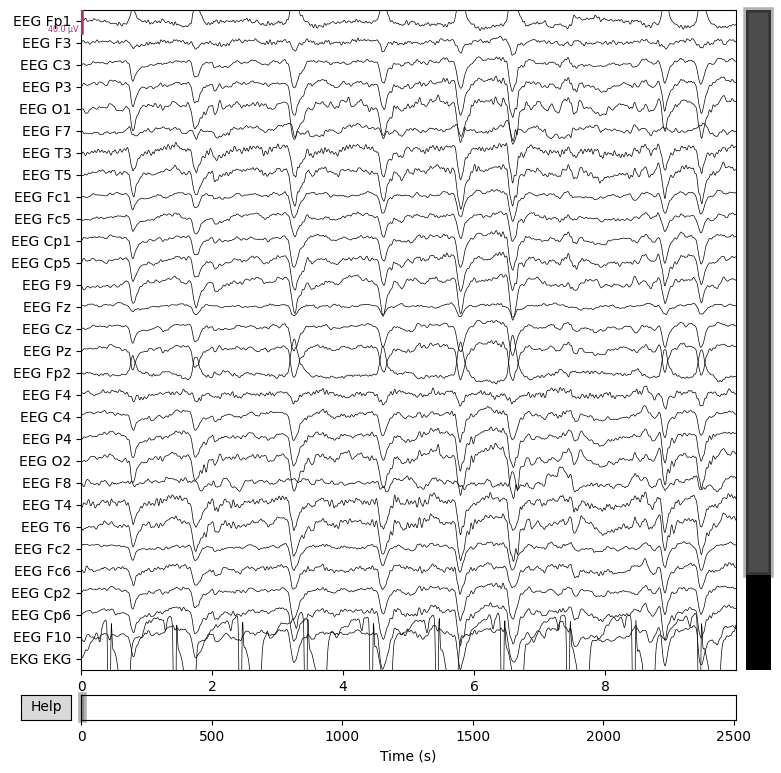

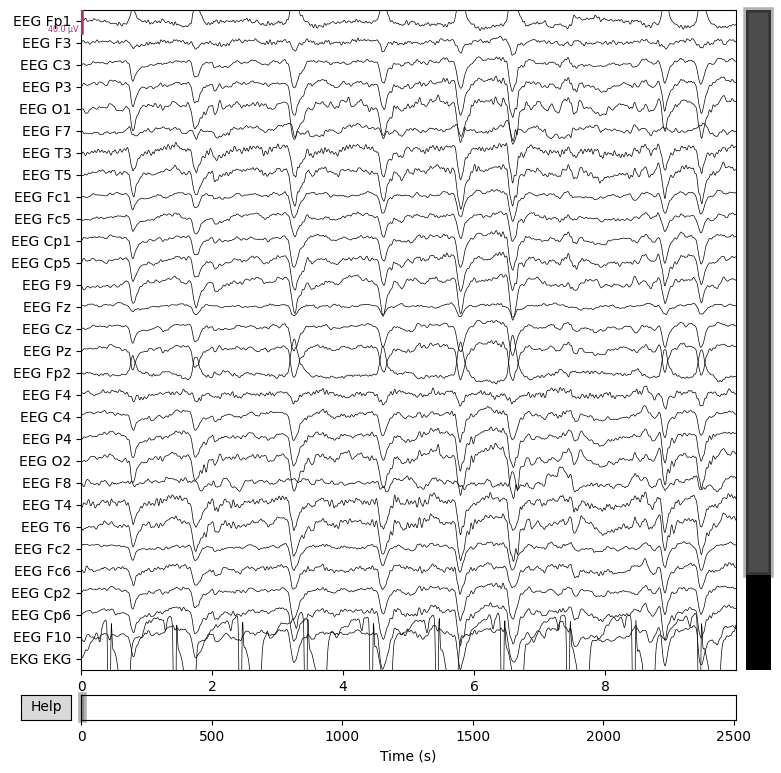

In [6]:
raw.plot(duration=10, n_channels=30)

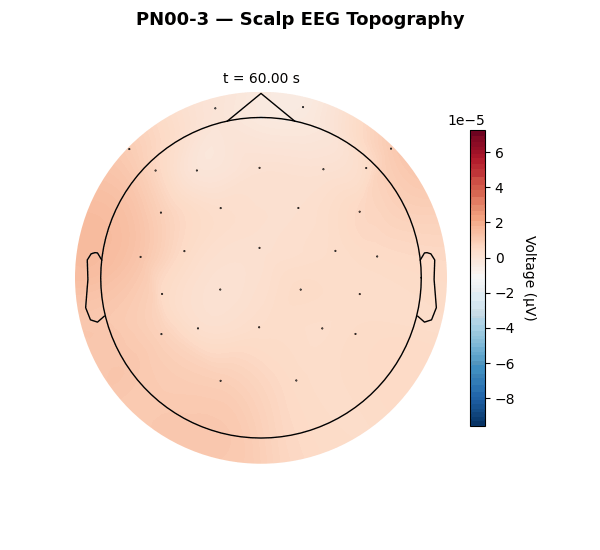

In [ ]:
plot_eeg_gif(raw, save_path="img.gif", fps=3)
Image("img.gif")